- # 흡연유무와 bmi수치별 진료비예측
    진료비 데이터를 분석하여 고객 진료비를 예측하는 회귀 모델 설계

- ### 데이터 출처  
    https://www.kaggle.com/datasets/mirichoi0218/insurance/data

- ### 목차
1. 데이터 읽기
2. EDA 및 데이터 정제
3. 데이터 시각화
4. 머신러닝 모델에 학습하기 위한 데이터 전처리
5. 모델 학습 및 평가
6. 고도화

In [697]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from sklearn.preprocessing import MinMaxScaler


from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression 
from xgboost import XGBRegressor    

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


## 1. 데이터 읽기

In [698]:
df = pd.read_csv('data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [699]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [700]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 2. 데이터 정제

In [701]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [702]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [703]:
# 범주형 변수 숫자형으로
df_corr = df.copy()
df_corr['sex'] = df_corr['sex'].map({'male': 1, 'female': 0})
df_corr['smoker'] = df_corr['smoker'].map({'yes': 1, 'no': 0})

# 지역변수 제거
df_corr = df_corr.drop('region', axis = 1)
df_corr

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520
...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830
1334,18,0,31.920,0,0,2205.98080
1335,18,0,36.850,0,0,1629.83350
1336,21,0,25.800,0,0,2007.94500


## 3. 데이터 시각화

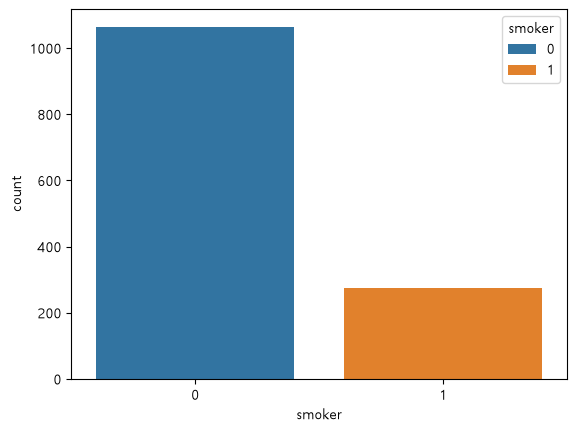

In [704]:
sns.countplot(x='smoker', data = df_corr,hue='smoker')
plt.show()

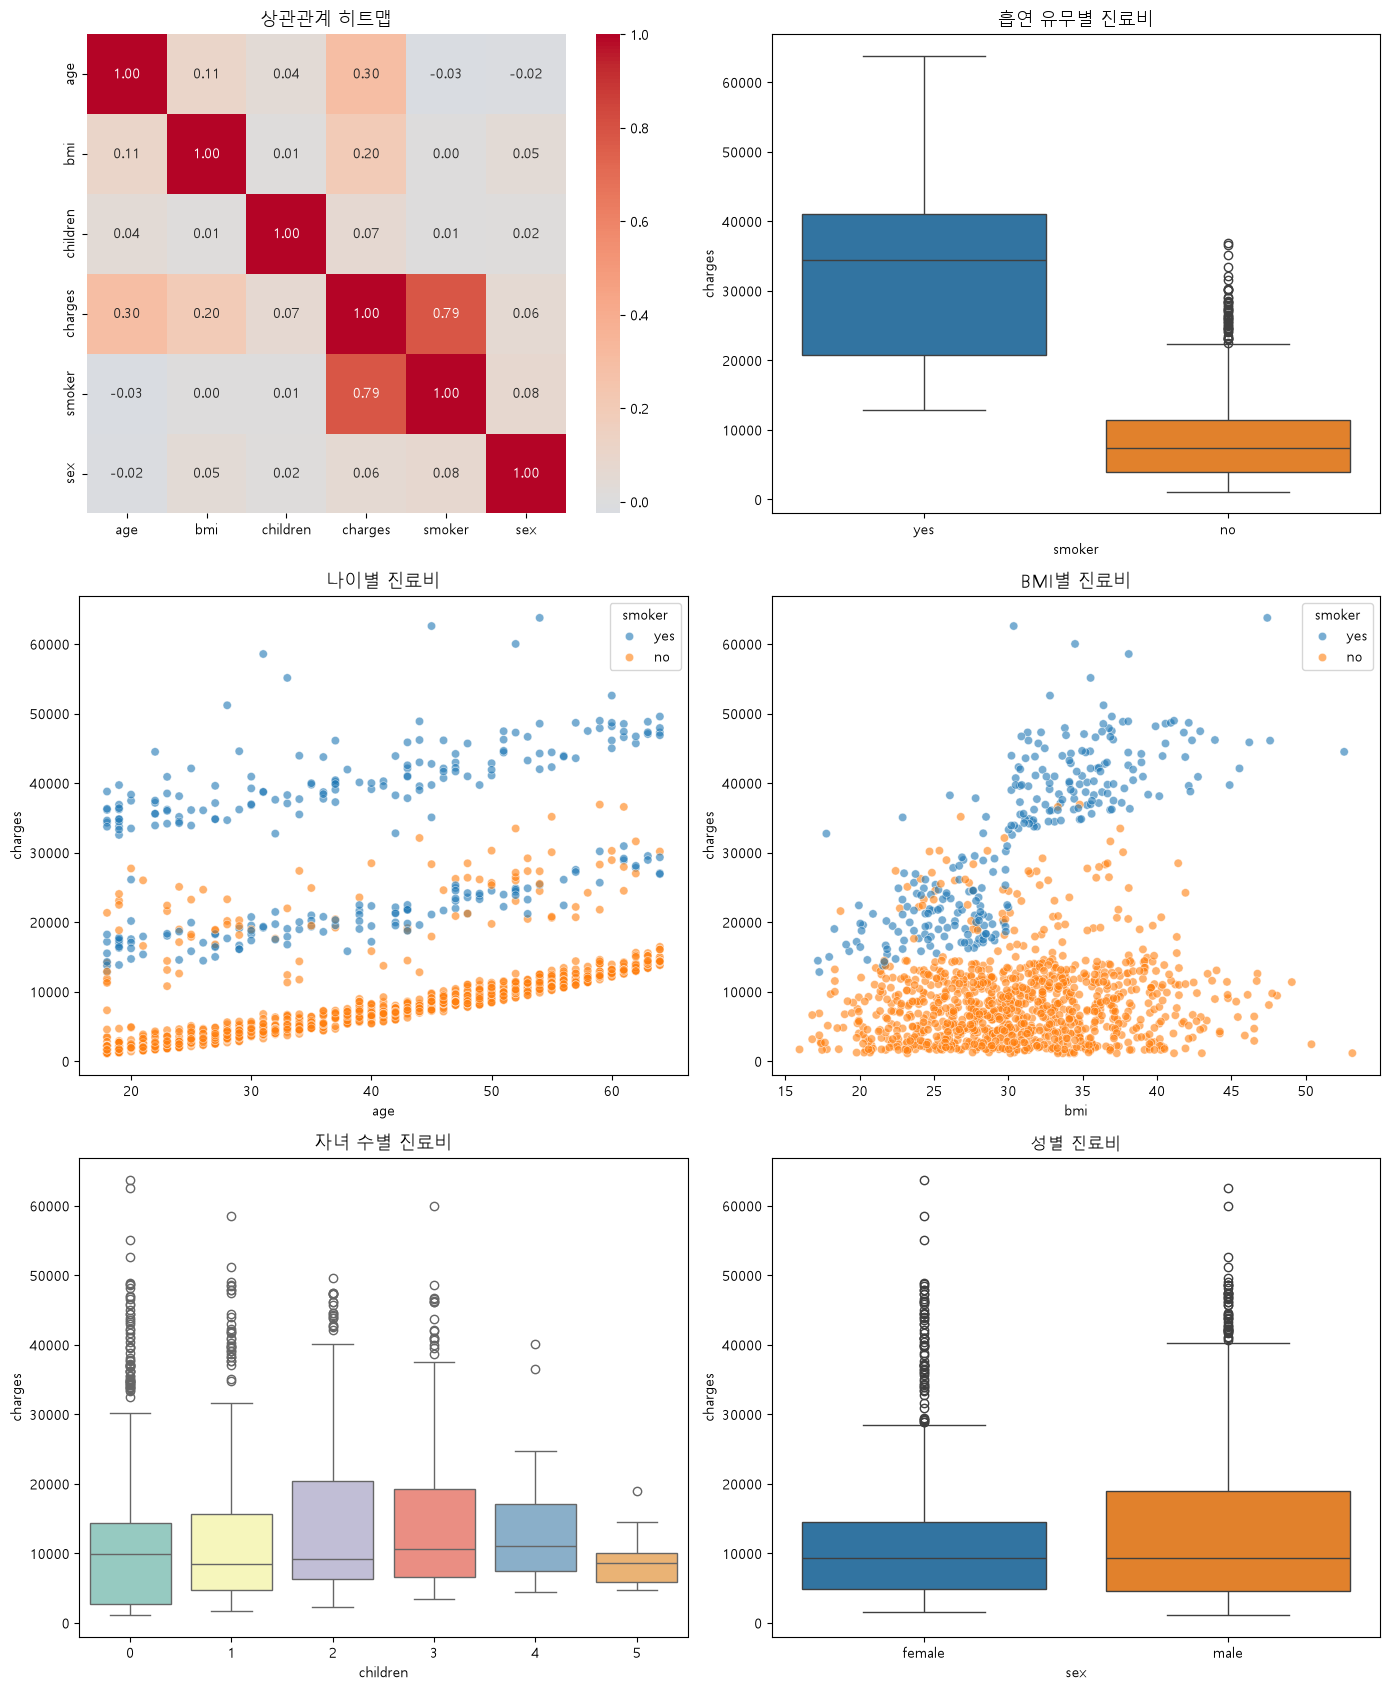

In [739]:
corr_cols = ['age', 'bmi', 'children', 'charges','smoker','sex']
corr = df_corr[corr_cols].corr()
 
fig, axes = plt.subplots(3, 2, figsize=(14, 17))
 

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0, 0], square=True)
axes[0, 0].set_title('상관관계 히트맵', fontsize=13)
 

sns.boxplot(data=df, x='smoker', y='charges', hue='smoker',
            legend=False, ax=axes[0, 1])
axes[0, 1].set_title('흡연 유무별 진료비', fontsize=13)
 

sns.scatterplot(data=df, x='age', y='charges', hue='smoker',
                 alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('나이별 진료비', fontsize=13)
 

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',
                 alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title('BMI별 진료비', fontsize=13)


sns.boxplot(data=df, x='children', y='charges', hue='children',
            legend=False, ax=axes[2, 0], palette='Set3')
axes[2, 0].set_title('자녀 수별 진료비', fontsize=13)
 
sns.boxplot(x="sex",y="charges",data=df,hue = 'sex')
axes[2, 1].set_title("성별 진료비")
# fig.delaxes(axes[2, 1])
plt.tight_layout()
plt.show()
 
 

In [706]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='charges'>

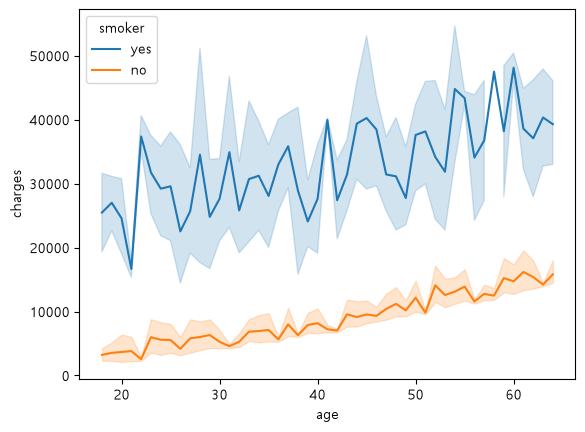

In [707]:

sns.lineplot(
    df,
    x = 'age',
    y = 'charges',
    hue = 'smoker',
    # kde = True,
)

## 4. 머신러닝 모델에 학습하기 위한 데이터 전처리

In [708]:
df_corr.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

In [709]:
df_corr

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520
...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830
1334,18,0,31.920,0,0,2205.98080
1335,18,0,36.850,0,0,1629.83350
1336,21,0,25.800,0,0,2007.94500


In [710]:
X = df_corr.drop(columns=['charges'])   
y = df_corr['charges']                


X['smoker_bmi'] = X['smoker'] * X['bmi']          # 흡연 x BMI 상호작용
X['smoker_age'] = X['smoker'] * X['age']           # 흡연 x 나이 상호작용
X['bmi_obese'] = (X['bmi'] >= 30).astype(int)          # 비만 여부(BMI>=30) 파생변수
X['smoker_obese'] = X['smoker'] * X['bmi_obese']   # 흡연 x 비만 상호작용

kf = KFold(n_splits=5, shuffle=True, random_state=42) # 교차검증


In [711]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     
    random_state=42,
    stratify=X['smoker']     
)

print('전체 데이터:', X.shape)
print('학습 데이터:', X_train.shape)
print('테스트 데이터:', X_test.shape)

전체 데이터: (1338, 9)
학습 데이터: (1070, 9)
테스트 데이터: (268, 9)


In [712]:
scaler = MinMaxScaler()

feature_names = X.columns.tolist()      # 특성 이름 리스트

numeric_features = ['age','bmi']

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features]) # 수치형 데이터를 기준으로 학습하고, 변환

X_test[numeric_features] = scaler.transform(X_test[numeric_features])  

In [713]:
# 예측값 함수
# 각종 평가 지표들을 한 번에 출력해서 확인하고 반환받는 함수
# ※ charges(진료비)는 연속값이므로 회귀 지표(R2, MAE, RMSE)를 사용
#   accuracy/precision/recall은 분류 전용이라 회귀에는 쓸 수 없음
def check_metrix(model, model_name, X_train, X_test, y_train, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    r2_train = r2_score(y_train, y_pred_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    print(f"{model_name}의 학습 R2스코어 : {r2_train:.4f}")
    print(f"{model_name}의 학습 MAE : {mae_train:,.0f}")
    print(f"{model_name}의 학습 RMSE : {rmse_train:,.0f}")
    print("-" * 20)
    print(f"{model_name}의 테스트 R2스코어 : {r2_test:.4f}")
    print(f"{model_name}의 테스트 MAE : {mae_test:,.0f}")
    print(f"{model_name}의 테스트 RMSE : {rmse_test:,.0f}")

    return {
        'model': model_name,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'mae_test': mae_test,
        'rmse_test': rmse_test,
    }


# 실제값 vs 예측값 산점도 함수
# ※ 분류가 아니라 회귀이므로 confusion_matrix 대신
#    실제값-예측값을 비교하는 산점도로 성능을 시각화
def plot_prediction(model, model_name, X_test, y_test):
    import matplotlib.pyplot as plt

    y_pred = model.predict(X_test)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='y = x (완벽 예측선)')
    plt.xlabel('실제값 (Actual charges)')
    plt.ylabel('예측값 (Predjicted charges)')
    plt.title(f"{model_name}: 실제값 vs 예측값")
    plt.legend()
    plt.show()

In [714]:
df_corr['smoker'].value_counts()

smoker
0    1064
1     274
Name: count, dtype: int64

## 5. 모델 학습 및 평가

In [715]:
# 회귀 모델 학습
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
 
print('LinearRegression 학습 완료')

LinearRegression 학습 완료


In [716]:
model_results = [] # 모델별 테스트 성능 결과 저장

In [717]:
result = check_metrix(lr_model, "LinearRegression", X_train,X_test,y_train,y_test)

model_results.append(result)

LinearRegression의 학습 R2스코어 : 0.8620
LinearRegression의 학습 MAE : 2,417
LinearRegression의 학습 RMSE : 4,494
--------------------
LinearRegression의 테스트 R2스코어 : 0.8820
LinearRegression의 테스트 MAE : 2,290
LinearRegression의 테스트 RMSE : 4,173


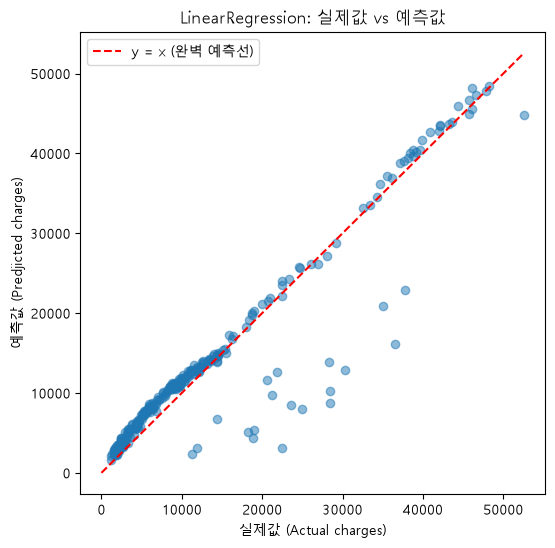

In [718]:
plot_prediction(lr_model,"LinearRegression",X_test,y_test)

In [719]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
 
print('RandomForestRegressor 학습 완료')

RandomForestRegressor 학습 완료


In [720]:
result = check_metrix(rf_model, "RandomForestRegressorression", X_train,X_test,y_train,y_test)

model_results.append(result)

RandomForestRegressorression의 학습 R2스코어 : 0.9744
RandomForestRegressorression의 학습 MAE : 1,031
RandomForestRegressorression의 학습 RMSE : 1,937
--------------------
RandomForestRegressorression의 테스트 R2스코어 : 0.8354
RandomForestRegressorression의 테스트 MAE : 2,850
RandomForestRegressorression의 테스트 RMSE : 4,927


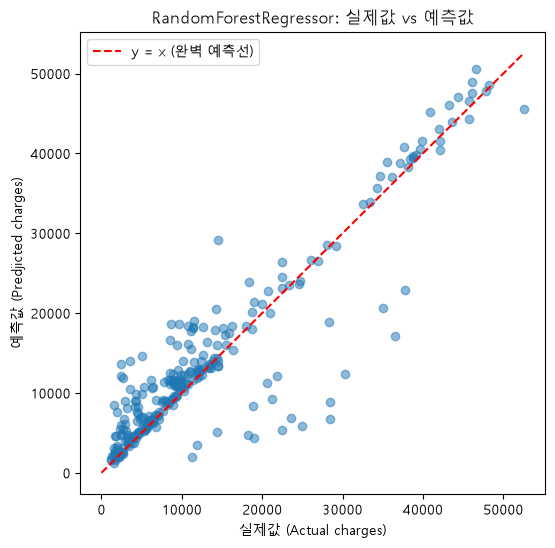

In [721]:
plot_prediction(rf_model,"RandomForestRegressor",X_test,y_test)

In [722]:
# 회귀 모델 학습

xg_model = XGBRegressor(random_state = 42)
xg_model.fit(X_train, y_train)
 
print('RandomForestRegressor 학습 완료')

RandomForestRegressor 학습 완료


In [723]:
result = check_metrix(xg_model, "XGboost", X_train,X_test,y_train,y_test)

model_results.append(result)

XGboost의 학습 R2스코어 : 0.9903
XGboost의 학습 MAE : 637
XGboost의 학습 RMSE : 1,191
--------------------
XGboost의 테스트 R2스코어 : 0.8164
XGboost의 테스트 MAE : 3,132
XGboost의 테스트 RMSE : 5,204


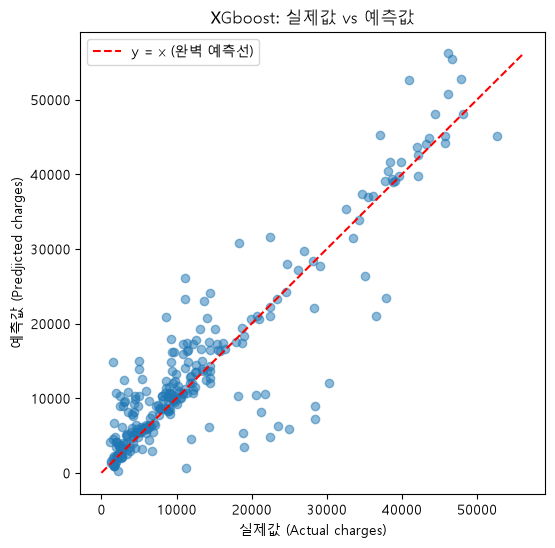

In [724]:
plot_prediction(xg_model,"XGboost",X_test,y_test)

In [725]:
result_df = pd.DataFrame(model_results)
result_df

,model,r2_train,r2_test,mae_test,rmse_test
0,LinearRegression,0.861976,0.881970,2289.600096,4172.933576
1,RandomForestRegressorression,0.974352,0.835447,2849.779679,4927.176065
2,XGboost,0.990300,0.816405,3131.630767,5204.460030


## 6. 고도화

In [735]:
baseline_models = {
    'LinearRegression': LinearRegression(),
    'RandomForest ': RandomForestRegressor(n_estimators=300, random_state=42),
    'XGBoost ': XGBRegressor(random_state=42, verbosity=0),
}
for name, model in baseline_models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    print(f'{name:22s} R2 평균: {scores.mean():.4f} (표준편차: {scores.std():.4f})')

LinearRegression       R2 평균: 0.8607 (표준편차: 0.0324)
RandomForest           R2 평균: 0.8263 (표준편차: 0.0328)
XGBoost                R2 평균: 0.8052 (표준편차: 0.0305)


In [727]:

lr_param_grid = {
    'fit_intercept': [True, False],
}
lr_grid = GridSearchCV(LinearRegression(), lr_param_grid,
                        cv=kf, scoring='r2', n_jobs=-1)
lr_grid.fit(X_train, y_train)
print('LinearRegression Best params:', lr_grid.best_params_)
print('LinearRegression Best CV R2:', round(lr_grid.best_score_, 4))
 
best_lr = lr_grid.best_estimator_
print(f"LinearRegression Train R2: {r2_score(y_train, best_lr.predict(X_train)):.4f} / "
      f"LinearRegression Test R2: {r2_score(y_test, best_lr.predict(X_test)):.4f}")
 
pred_test = best_lr.predict(X_test)
print(f"Test MAE: {mean_absolute_error(y_test, pred_test):,.0f}, "
      f"Test RMSE: {np.sqrt(mean_squared_error(y_test, pred_test)):,.0f}")
 
 
rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 4, 5, 6],
    'min_samples_leaf': [5, 10, 20],
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid,
                        cv=kf, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print('RandomForestRegressor Best params:', rf_grid.best_params_)
print('RandomForestRegressor Best CV R2:', round(rf_grid.best_score_, 4))
 
best_rf = rf_grid.best_estimator_
print(f"RandomForestRegressor Train R2: {r2_score(y_train, best_rf.predict(X_train)):.4f} / "
      f"RandomForestRegressor Test R2: {r2_score(y_test, best_rf.predict(X_test)):.4f}")
 
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_lambda': [1, 5],
}
xgb_grid = GridSearchCV(XGBRegressor(random_state=42, verbosity=0), xgb_param_grid,
                         cv=kf, scoring='r2', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
print('XGBRegressor Best params:', xgb_grid.best_params_)
print('XGBRegressor Best CV R2:', round(xgb_grid.best_score_, 4))
 
best_xgb = xgb_grid.best_estimator_
pred_test = best_xgb.predict(X_test)
print(f"XGBRegressor Train R2: {r2_score(y_train, best_xgb.predict(X_train)):.4f} / "
      f"XGBRegressor Test R2: {r2_score(y_test, pred_test):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, pred_test):,.0f}, "
      f"Test RMSE: {np.sqrt(mean_squared_error(y_test, pred_test)):,.0f}")
 

LinearRegression Best params: {'fit_intercept': True}
LinearRegression Best CV R2: 0.8617
LinearRegression Train R2: 0.8620 / LinearRegression Test R2: 0.8820
Test MAE: 2,290, Test RMSE: 4,173
RandomForestRegressor Best params: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 300}
RandomForestRegressor Best CV R2: 0.8569
RandomForestRegressor Train R2: 0.8737 / RandomForestRegressor Test R2: 0.8756
XGBRegressor Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_lambda': 1, 'subsample': 0.8}
XGBRegressor Best CV R2: 0.86
XGBRegressor Train R2: 0.8801 / XGBRegressor Test R2: 0.8795
Test MAE: 2,398, Test RMSE: 4,217


In [728]:
best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

LinearRegression(튜닝)의 학습 R2스코어 : 0.8620
LinearRegression(튜닝)의 학습 MAE : 2,417
LinearRegression(튜닝)의 학습 RMSE : 4,494
--------------------
LinearRegression(튜닝)의 테스트 R2스코어 : 0.8820
LinearRegression(튜닝)의 테스트 MAE : 2,290
LinearRegression(튜닝)의 테스트 RMSE : 4,173


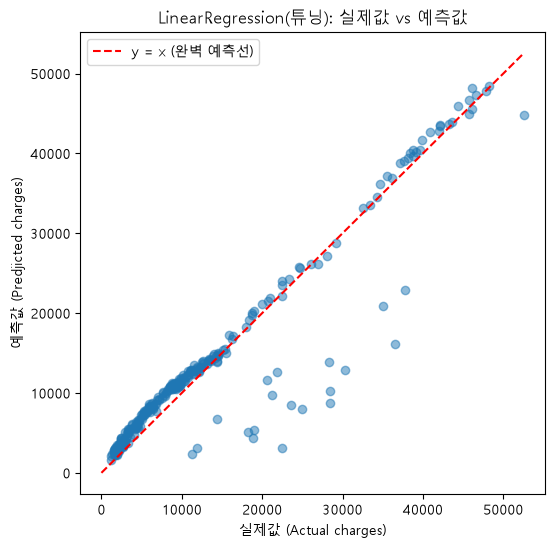

In [729]:
# ---  평가 ---
result = check_metrix(best_lr, 'LinearRegression(튜닝)', X_train, X_test, y_train, y_test)
plot_prediction(best_lr, 'LinearRegression(튜닝)', X_test, y_test)
 
model_results.append(result)


RandomForest(튜닝)의 학습 R2스코어 : 0.8737
RandomForest(튜닝)의 학습 MAE : 2,410
RandomForest(튜닝)의 학습 RMSE : 4,298
--------------------
RandomForest(튜닝)의 테스트 R2스코어 : 0.8756
RandomForest(튜닝)의 테스트 MAE : 2,501
RandomForest(튜닝)의 테스트 RMSE : 4,284


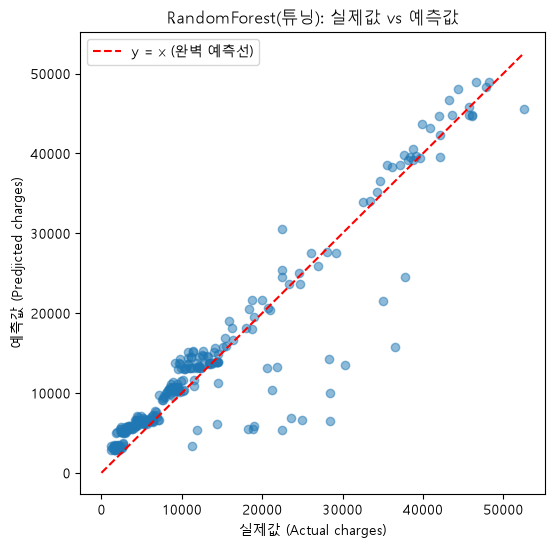

In [730]:
# --- RandomForest 평가 ---
result = check_metrix(best_rf, 'RandomForest(튜닝)', X_train, X_test, y_train, y_test)
plot_prediction(best_rf, 'RandomForest(튜닝)', X_test, y_test)
 
model_results.append(result)


XGBoost(튜닝)의 학습 R2스코어 : 0.8801
XGBoost(튜닝)의 학습 MAE : 2,307
XGBoost(튜닝)의 학습 RMSE : 4,188
--------------------
XGBoost(튜닝)의 테스트 R2스코어 : 0.8795
XGBoost(튜닝)의 테스트 MAE : 2,398
XGBoost(튜닝)의 테스트 RMSE : 4,217


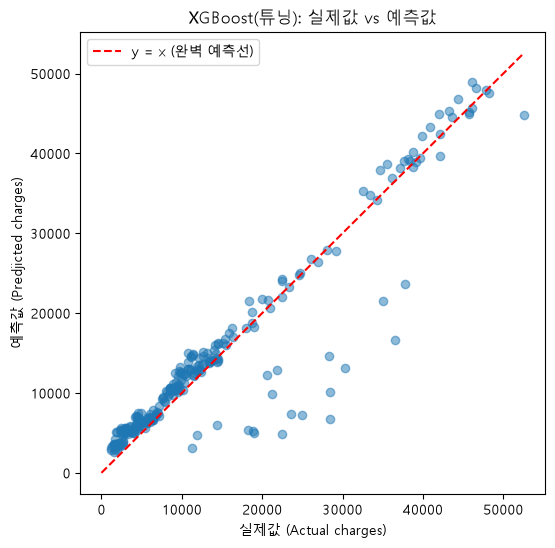

In [731]:
# --- XGBoost 평가 ---
result = check_metrix(best_xgb, 'XGBoost(튜닝)', X_train, X_test, y_train, y_test)
plot_prediction(best_xgb, 'XGBoost(튜닝)', X_test, y_test)
 
model_results.append(result)

In [732]:
result_df = pd.DataFrame(model_results)
result_df
 

,model,r2_train,r2_test,mae_test,rmse_test
0,LinearRegression,0.861976,0.881970,2289.600096,4172.933576
1,RandomForestRegressorression,0.974352,0.835447,2849.779679,4927.176065
2,XGboost,0.990300,0.816405,3131.630767,5204.460030
3,LinearRegression(튜닝),0.861976,0.881970,2289.600096,4172.933576
4,RandomForest(튜닝),0.873748,0.875599,2501.049642,4284.077444
5,XGBoost(튜닝),0.880113,0.879461,2397.682754,4217.049646


In [733]:
df_corr.head()

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520


성능면에선 LinearRegression가 1위이지만 나중에 데이터가 더 모였을때를 생각해 모델을 XG부스트로 정했다.

In [736]:
import joblib
import os


bundle = {
    'model': best_xgb,                    
    'scaler': scaler,
    'scale_features': numeric_features,
    'feature_order': X.columns.tolist(),
    'obese_threshold': 30,
    'model_name': 'XGBoost',
    'test_r2': 0.8795,
    'test_mae': 2398,
    'test_rmse': 4217,
}

joblib.dump(bundle, 'models/best_model.joblib')
print('저장 완료: models/best_model.joblib')

저장 완료: models/best_model.joblib
